# 05 — Visualize Results


In [1]:
import csv
import gc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from research_ct.io.volume_saver import Load_From_Numpy, Load_From_Numpy_Slab
from research_ct.analysis.material_stats import Compute_Material_Statistics, Print_Material_Report
from research_ct.analysis.uncertainty_maps import Compute_Uncertainty, Compute_Margin

In [2]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data paths
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load all outputs (lazy memmap — no data enters RAM until indexed)
Processed = Load_From_Numpy(PROCESSED_DATA_DIR / "preprocessed_volume.npz")
Labels = Load_From_Numpy(OUTPUT_DATA_DIR / "gmm_labels.npy")
Probs = Load_From_Numpy(OUTPUT_DATA_DIR / "gmm_probabilities.npy")

print(f"Processed: {Processed.shape}")
print(f"Labels: {Labels.shape}")
print(f"Probabilities: {Probs.shape}")

# Number of material classes
Num_Classes = int(Labels.max() + 1)
print(f"Number of classes: {Num_Classes}")

[Load_From_Numpy] Loaded (lazy): (201, 1734, 1705)  (2.38 GB on disk)
[Load_From_Numpy] Loaded (lazy): (201, 1734, 1705)  (2.38 GB on disk)
[Load_From_Numpy] Loaded (lazy): (201, 1734, 1705, 4)  (9.51 GB on disk)
Processed: (201, 1734, 1705)
Labels: (201, 1734, 1705)
Probabilities: (201, 1734, 1705, 4)
Number of classes: 4


## Material Statistics Report

Print quantitative summary of segmented materials and export as CSV.

In [4]:
Stats = Compute_Material_Statistics(Processed, Labels, Num_Classes)
Print_Material_Report(Stats)


MATERIAL STATISTICS
Total voxels: 594,250,470
Global mean: 0.17
Global std: 0.09
------------------------------------------------------------
Class    Count        Fraction     Mean       Std       
------------------------------------------------------------
0        493,354,175  0.8302       0.17       0.03      
1        32,672,713   0.0550       0.30       0.05      
2        59,703,054   0.1005       0.00       0.00      
3        8,520,528    0.0143       0.61       0.17      


In [5]:
# Export material statistics as CSV
Csv_Path = OUTPUT_DATA_DIR / "material_stats.csv"
with open(Csv_Path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Class", "Voxel_Count", "Volume_Fraction",
                     "Mean_Intensity", "Std_Intensity",
                     "Min_Intensity", "Max_Intensity"])
    for C in Stats["classes"]:
        writer.writerow([
            C["class_id"],
            C["voxel_count"],
            f"{C['volume_fraction']:.6f}",
            f"{C['mean_intensity']:.2f}",
            f"{C['std_intensity']:.2f}",
            f"{C['min_intensity']:.2f}",
            f"{C['max_intensity']:.2f}",
        ])
print(f"Saved material stats CSV → {Csv_Path}")

Saved material stats CSV → c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\material_stats.csv


## Uncertainty Maps

Identify regions where the segmentation is ambiguous.  High entropy = high uncertainty; small margin = class ambiguity.

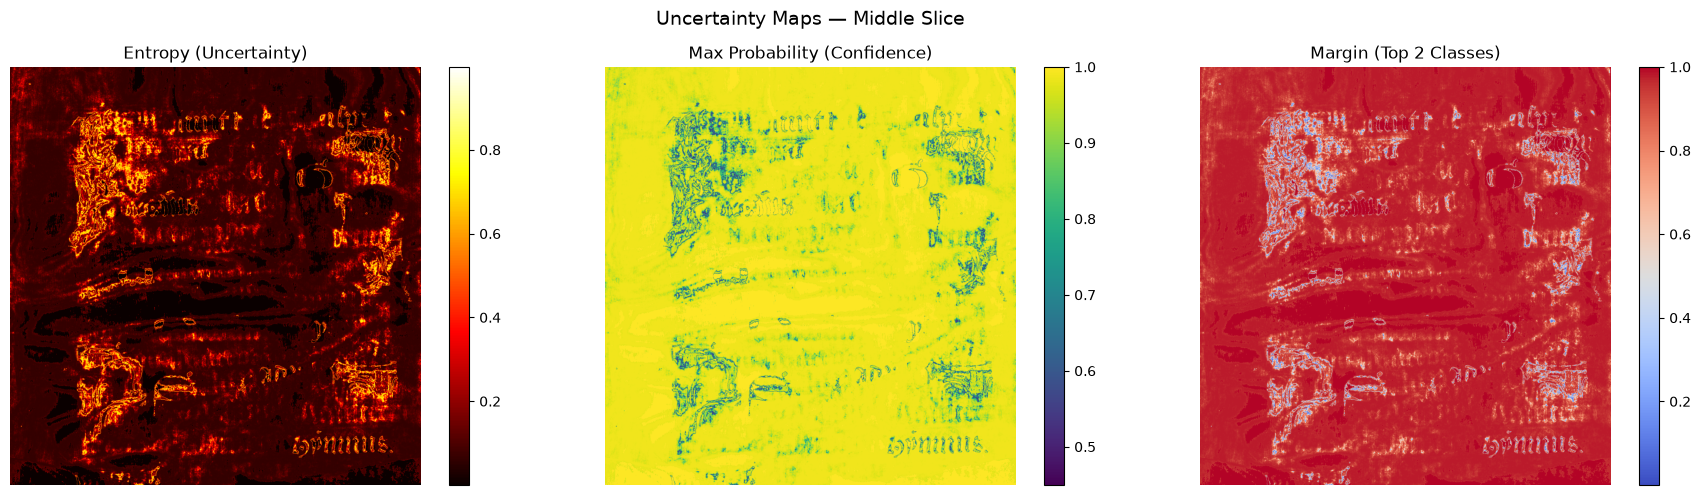

In [6]:
Entropy, Max_Prob = Compute_Uncertainty(Probs)
Margin = Compute_Margin(Probs, Top_K=2)

Mid_Z = Processed.shape[0] // 4

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(Entropy[Mid_Z], cmap="hot")
axes[0].set_title("Entropy (Uncertainty)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(Max_Prob[Mid_Z], cmap="viridis")
axes[1].set_title("Max Probability (Confidence)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(Margin[Mid_Z], cmap="coolwarm")
axes[2].set_title("Margin (Top 2 Classes)")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle("Uncertainty Maps — Middle Slice", fontsize=14)
plt.tight_layout()
plt.show()

## Interactive Probability Thresholding

Use the sliders to explore probability maps per class.  Adjust the threshold and Z-slice to see where each class is confident.

In [7]:
from ipywidgets import interact, FloatSlider, IntSlider

def show_probability_threshold(
    class_idx: int = 0,
    threshold: float = 0.5,
    z_slice: int = 0,
) -> None:
    """Display probability map and binary threshold mask."""
    z_slice = max(0, min(z_slice, Probs.shape[0] - 1))
    # Materialize one slice from memmap
    prob_slice = np.array(Probs[z_slice, :, :, class_idx], copy=True)
    mask = prob_slice > threshold

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(prob_slice, cmap="magma", vmin=0, vmax=1)
    axes[0].set_title(f"P(class={class_idx}) — Z={z_slice}")
    axes[0].axis("off")
    plt.colorbar(
        axes[0].images[0], ax=axes[0], fraction=0.046, label="Probability"
    )

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(
        f"P(class={class_idx}) > {threshold}  "
        f"({mask.sum():,} voxels)"
    )
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

interact(
    show_probability_threshold,
    class_idx=IntSlider(
        min=0, max=Num_Classes - 1, step=1, value=0, description="Class"
    ),
    threshold=FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.5, description="Threshold"
    ),
    z_slice=IntSlider(
        min=0,
        max=Probs.shape[0] - 1,
        step=1,
        value=Probs.shape[0] // 4,
        description="Z Slice",
    ),
);

interactive(children=(IntSlider(value=0, description='Class', max=3), FloatSlider(value=0.5, description='Thre…

## Component Distribution Plots

Generate publication-quality GMM decomposition figure.

In [8]:
from research_ct.visualization.plot_distributions import plot_gmm_components
from research_ct.segmentation.gmm_fitter import Gmm_Fitter

# Re-fit on sample for plotting
sample_flat = np.random.choice(
    Processed.ravel(), 200_000, replace=False
)
Fitter = Gmm_Fitter(Min_Components=Num_Classes, Max_Components=Num_Classes)
Fitter.Fit(sample_flat.reshape(-1, 1), Verbose=False)

fig = plot_gmm_components(
    sample_flat,
    Fitter.Model,
    Output_Path=FIGURES_DIR / "gmm_decomposition.png",
)
plt.show()
print("Saved: data/output/figures/gmm_decomposition.png")

Saved: data/output/figures/gmm_decomposition.png


C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_4004\2181620824.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Slice-Wise Uncertainty Profile

Mean entropy and confidence per Z-slice.  Detects non-stationary ambiguity across the volume.

In [9]:
# Compute mean entropy & confidence per Z-slice
z_indices = range(0, Probs.shape[0], 2)  # every other slice
mean_entropy = []
mean_confidence = []

for z in z_indices:
    slab = np.array(Probs[z : z + 1], copy=True).squeeze(0)  # (H, W, K)
    clipped = np.clip(slab, 1e-10, 1.0)
    ent = -np.sum(clipped * np.log(clipped), axis=2)
    conf = slab.max(axis=2)
    mean_entropy.append(float(ent.mean()))
    mean_confidence.append(float(conf.mean()))
    del slab, clipped, ent, conf
    if z % 20 == 0:
        gc.collect()
        print(f"  processed Z={z}/{Probs.shape[0]}")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(list(z_indices), mean_entropy, "r-", label="Mean entropy", linewidth=2)
ax1.set_xlabel("Z slice")
ax1.set_ylabel("Mean entropy", color="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    list(z_indices),
    mean_confidence,
    "b--",
    label="Mean confidence",
    linewidth=2,
)
ax2.set_ylabel("Mean confidence", color="b")
ax2.tick_params(axis="y", labelcolor="b")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.title("Slice-Wise Uncertainty Profile")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "slice_uncertainty_profile.png", dpi=150)
plt.show()

  processed Z=0/201
  processed Z=20/201
  processed Z=40/201
  processed Z=60/201
  processed Z=80/201
  processed Z=100/201
  processed Z=120/201
  processed Z=140/201
  processed Z=160/201
  processed Z=180/201
  processed Z=200/201


C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_4004\3109503655.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Per-Slice Material Fractions

Class volume fraction vs. Z-slice.  Detects drift or non-stationarity in material composition.

In [10]:
# Compute material fractions per Z-slice (every 5th slice)
step = 5
slice_rows = []

for z in range(0, Probs.shape[0], step):
    slab = np.array(Probs[z : z + 1], copy=True).squeeze(0)  # (H, W, K)
    labels_slab = slab.argmax(axis=-1)
    row = {"slice": z}
    for k in range(Num_Classes):
        row[f"class_{k}_frac"] = float((labels_slab == k).mean())
    slice_rows.append(row)
    del slab, labels_slab

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
z_vals = [r["slice"] for r in slice_rows]
for k in range(Num_Classes):
    fracs = [r[f"class_{k}_frac"] for r in slice_rows]
    ax.plot(z_vals, fracs, "o-", linewidth=2, markersize=3, label=f"Class {k}")
ax.set_xlabel("Z slice")
ax.set_ylabel("Volume fraction")
ax.set_title("Per-Slice Material Fractions")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_slice_fractions.png", dpi=150)
plt.show()

# Export CSV
frac_csv = OUTPUT_DATA_DIR / "per_slice_material_fractions.csv"
fieldnames = ["slice"] + [f"class_{k}_frac" for k in range(Num_Classes)]
with open(frac_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(slice_rows)
print(f"Saved → {frac_csv}")

Saved → c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\per_slice_material_fractions.csv


C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_4004\2335595499.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Uncertainty vs. Intensity Scatter

Scatter of entropy vs. voxel intensity, colored by class.  Helps distinguish boundary ambiguity from intensity-noise ambiguity.

In [11]:
# Sample from a middle Z-slice for scatter plot
Mid_Z_Single = Processed.shape[0] // 4
slab_probs = np.array(Probs[Mid_Z_Single : Mid_Z_Single + 1], copy=True).squeeze(0)
slab_vol = np.array(Processed[Mid_Z_Single : Mid_Z_Single + 1], copy=True).squeeze(0)

H, W = slab_vol.shape
n_sample = 50_000
y_rand = np.random.randint(0, H, n_sample)
x_rand = np.random.randint(0, W, n_sample)

probs_sample = slab_probs[y_rand, x_rand, :]
intensity_sample = slab_vol[y_rand, x_rand]

entropy_sample = -np.sum(
    probs_sample * np.log(np.clip(probs_sample, 1e-10, 1.0)), axis=1
)
maxprob_sample = probs_sample.max(axis=1)
label_sample = probs_sample.argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(
    intensity_sample,
    entropy_sample,
    c=maxprob_sample,
    cmap="viridis_r",
    alpha=0.3,
    s=2,
)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Entropy")
axes[0].set_title(f"Entropy vs. Intensity (Z={Mid_Z_Single})")
plt.colorbar(sc, ax=axes[0], label="Max Probability")

for k in range(Num_Classes):
    mask = label_sample == k
    axes[1].scatter(
        intensity_sample[mask],
        maxprob_sample[mask],
        alpha=0.3,
        s=2,
        label=f"Class {k}",
    )
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Max Probability")
axes[1].set_title("Max Probability vs. Intensity (by class)")
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "uncertainty_vs_intensity.png", dpi=150)
plt.show()

C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_4004\3238913867.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
from research_ct.visualization.napari_viewer import launch_napari_viewer

Viewer = launch_napari_viewer(
    Volume=Processed,
    Labels=Labels,
    Probabilities=Probs,
    Entropy=Entropy,              # hot-colormap overlay, opacity=0.35
    Probability_Threshold=0.3,
    Render_3d=False,
    Title="micro-CT Segmentation Results",
)